# 1. Set up the analysis
Prepare the folders, libraries, and plotting defaults used throughout the workflow.

In [27]:
# Import libraries and define output folders
from pathlib import Path
import re
import unicodedata
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
INBOX_DIR = BASE_DIR / "data" / "inbox"
OUTPUT_DIR = BASE_DIR / "outputs"
TEMP_DIR = BASE_DIR / "temp"
OUTPUT_DIR.mkdir(exist_ok=True)
TEMP_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False
print(f"Input folder: {INBOX_DIR}")

Input folder: c:\Users\ajou\OneDrive\OneDrive - Ajou University\6. 기타개인\1. SKK GSB BAMBA\2. 2026-fall semester\5. 수업\4. Programming for Analytics_BAM5103_01(캄푸이스핌)\BAM5103\data\inbox


# 2. Read and standardize source files
Discover every CSV and Excel file, map inconsistent headers to one schema, and retain the source filename for auditability.

In [28]:
# Define the canonical schema and header aliases
STANDARD_COLUMNS = ["expense_id", "date", "department", "category", "vendor", "amount", "status", "employee_id", "description"]
HEADER_ALIASES = {
    "expense_id": {"expense_id", "expense id", "id", "transaction_id", "transaction id", "expense_no", "지출id", "지출번호", "경비id", "전표번호"},
    "date": {"date", "expense_date", "expense date", "transaction_date", "transaction date", "일자", "날짜", "지출일", "사용일"},
    "department": {"department", "department_name", "dept", "team", "부서", "부서명"},
    "category": {"category", "expense_category", "expense type", "type", "cost category", "항목", "카테고리", "지출항목"},
    "vendor": {"vendor", "merchant", "supplier", "거래처"},
    "amount": {"amount", "amount krw", "expense_amount", "cost", "price", "total", "금액", "금액(원)", "지출액", "비용"},
    "status": {"status", "approval_status", "approval status", "approved?", "approval", "결재상태", "승인상태", "상태"},
    "employee_id": {"employee id", "employee_id", "employee", "staff id", "사번"},
    "description": {"description", "memo", "note", "details", "내역", "적요", "내용", "비고"},
}

def normalize_text(value):
    value = unicodedata.normalize("NFKC", str(value)).strip().lower()
    return re.sub(r"[\s_\-/]+", " ", value)

ALIAS_LOOKUP = {normalize_text(alias): standard for standard, aliases in HEADER_ALIASES.items() for alias in aliases}

In [29]:
# Read each file and rename recognized columns
input_files = sorted([p for p in INBOX_DIR.iterdir() if p.suffix.lower() in {".csv", ".xlsx", ".xls"}])
frames = []
unrecognized_columns = {}
for file_path in input_files:
    if file_path.suffix.lower() == ".csv":
        source = pd.read_csv(file_path)
    else:
        source = pd.read_excel(file_path)
    rename_map = {}
    unknown = []
    for column in source.columns:
        standard_name = ALIAS_LOOKUP.get(normalize_text(column))
        if standard_name:
            rename_map[column] = standard_name
        else:
            unknown.append(str(column))
    source = source.rename(columns=rename_map)
    for column in STANDARD_COLUMNS:
        if column not in source.columns:
            source[column] = pd.NA
    source = source[STANDARD_COLUMNS].copy()
    source["source_filename"] = file_path.name
    frames.append(source)
    if unknown:
        unrecognized_columns[file_path.name] = unknown

if not frames:
    raise FileNotFoundError(f"No CSV or Excel files found in {INBOX_DIR}")
df = pd.concat(frames, ignore_index=True)
print(f"Read {len(input_files)} files and {len(df):,} rows.")
if unrecognized_columns:
    print("Unrecognized columns retained only in the source audit log:", unrecognized_columns)

Read 24 files and 539 rows.


# 3. Clean labels, dates, and amounts
Convert mixed English, abbreviated, and Korean values into consistent reporting labels, then derive a calendar month.

In [30]:
# Standardize common department, category, and status labels
def clean_label(value):
    return normalize_text(value).replace(" ", "") if pd.notna(value) else pd.NA

DEPARTMENT_MAP = {"marketing": "Marketing", "mkt": "Marketing", "마케팅": "Marketing", "sales": "Sales", "sls": "Sales", "영업": "Sales", "operations": "Operations", "ops": "Operations", "운영": "Operations", "hr": "HR", "humanresources": "HR", "인사": "HR"}
CATEGORY_MAP = {"travel": "Travel", "출장": "Travel", "meals": "Meals", "meal": "Meals", "식비": "Meals", "office": "Office Supplies", "officesupplies": "Office Supplies", "사무용품": "Office Supplies", "supplies": "Office Supplies", "software": "Software", "소프트웨어": "Software", "training": "Training", "교육": "Training"}
STATUS_MAP = {"approved": "Approved", "approve": "Approved", "승인": "Approved", "결재완료": "Approved", "pending": "Pending", "검토중": "Pending", "대기": "Pending", "rejected": "Rejected", "reject": "Rejected", "거절": "Rejected", "반려": "Rejected"}

df["department"] = df["department"].map(lambda value: DEPARTMENT_MAP.get(clean_label(value), value))
df["category"] = df["category"].map(lambda value: CATEGORY_MAP.get(clean_label(value), value))
df["status"] = df["status"].map(lambda value: STATUS_MAP.get(clean_label(value), value))

# Parse mixed date formats and amounts with thousands separators
df["date"] = pd.to_datetime(df["date"], errors="coerce", format="mixed")
df["amount"] = (df["amount"].astype("string").str.replace(r"[^0-9.\-()]", "", regex=True).str.replace(r"^\((.*)\)$", r"-\1", regex=True))
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
df["month"] = df["date"].dt.to_period("M").astype("string")
print(df[["date", "amount", "month"]].dtypes)

date      datetime64[us]
amount           Float64
month             string
dtype: object


# 4. Run quality checks and save review files
Check the date range, duplicate identifiers, and missing required values before producing reporting outputs.

In [31]:
# Report quality checks and export incomplete rows
required_columns = ["expense_id", "date", "department", "category", "amount", "status"]
missing_rows = df[df.isna().any(axis=1)].copy()
duplicate_ids = df[df["expense_id"].notna() & df["expense_id"].duplicated(keep=False)].copy()
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Duplicate expense IDs:", duplicate_ids["expense_id"].nunique())
print("Missing values by column:")
print(df.isna().sum())
missing_rows.to_excel(OUTPUT_DIR / "missing_values.xlsx", index=False)
print(f"Saved {len(missing_rows):,} rows to missing_values.xlsx")

Date range: 2026-01-01 00:00:00 to 2026-06-27 00:00:00
Duplicate expense IDs: 0
Missing values by column:
expense_id          0
date                0
department          0
category            0
vendor              0
amount              1
status              0
employee_id         0
description        33
source_filename     0
month               0
dtype: int64
Saved 34 rows to missing_values.xlsx


# 5. Create a reproducible audit sample
Save 100 randomly selected rows using the requested fixed random seed for repeatable review.

In [32]:
# Sample up to 100 rows reproducibly
audit_sample = df.sample(n=min(100, len(df)), random_state=50)
audit_sample.to_excel(TEMP_DIR / "audit_sample.xlsx", index=False)
print(f"Saved {len(audit_sample):,} rows to temp/audit_sample.xlsx")

Saved 100 rows to temp/audit_sample.xlsx


# 6. Build approved-expense summaries
Use only approved expenses for the monthly and department/category reporting tables.

In [33]:
# Aggregate approved expenses
approved = df[df["status"] == "Approved"].copy()
monthly_summary = approved.groupby("month", dropna=False, as_index=False)["amount"].sum().rename(columns={"amount": "total_amount_krw"})
department_summary = approved.groupby("department", dropna=False, as_index=False)["amount"].sum().rename(columns={"amount": "total_amount_krw"}).sort_values("total_amount_krw", ascending=False)
category_summary = approved.groupby(["department", "category"], dropna=False, as_index=False)["amount"].sum().rename(columns={"amount": "total_amount_krw"})
print(f"Approved rows: {len(approved):,}")
monthly_summary

Approved rows: 316


,month,total_amount_krw
0,2026-01,39194000.0
1,2026-02,29945000.0
2,2026-03,45871000.0
3,2026-04,40500000.0
4,2026-05,42793000.0
5,2026-06,43229000.0


# 7. Export clean data and summaries
Write the cleaned dataset and separate English and Korean summary workbooks to the outputs folder.

In [34]:
# Export clean data and reporting tables
df.to_excel(OUTPUT_DIR / "clean_expenses.xlsx", index=False)
with pd.ExcelWriter(OUTPUT_DIR / "english_summaries.xlsx") as writer:
    monthly_summary.to_excel(writer, sheet_name="Monthly totals", index=False)
    department_summary.to_excel(writer, sheet_name="Department totals", index=False)
    category_summary.to_excel(writer, sheet_name="Department category", index=False)
with pd.ExcelWriter(OUTPUT_DIR / "korean_summaries.xlsx") as writer:
    monthly_summary.rename(columns={"month": "월", "total_amount_krw": "총액(원)"}).to_excel(writer, sheet_name="월별 합계", index=False)
    department_summary.rename(columns={"department": "부서", "total_amount_krw": "총액(원)"}).to_excel(writer, sheet_name="부서별 합계", index=False)
    category_summary.rename(columns={"department": "부서", "category": "카테고리", "total_amount_krw": "총액(원)"}).to_excel(writer, sheet_name="부서 및 카테고리", index=False)
print("Excel exports completed.")

Excel exports completed.


# 8. Create executive charts
Save English monthly and department charts plus a Korean department chart, with department amounts displayed in KRW millions.

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

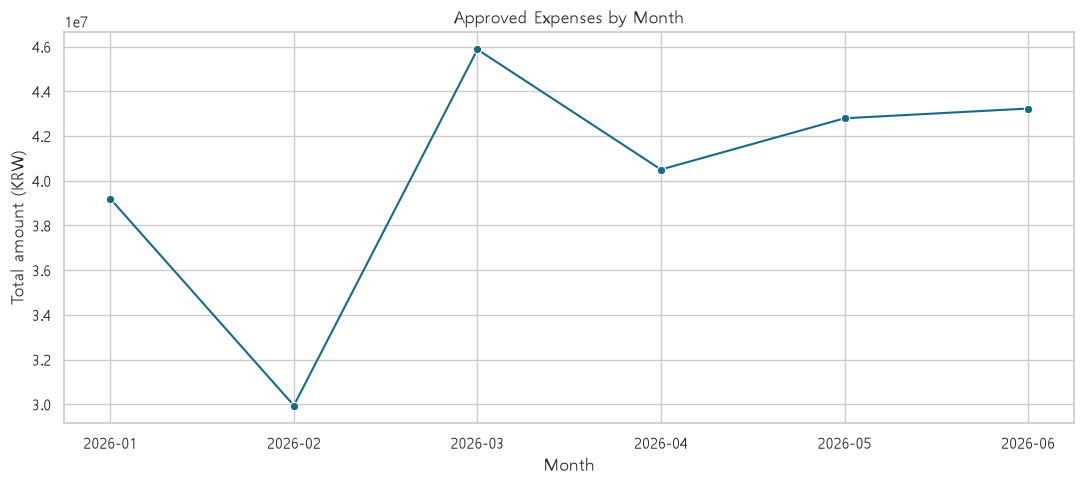

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

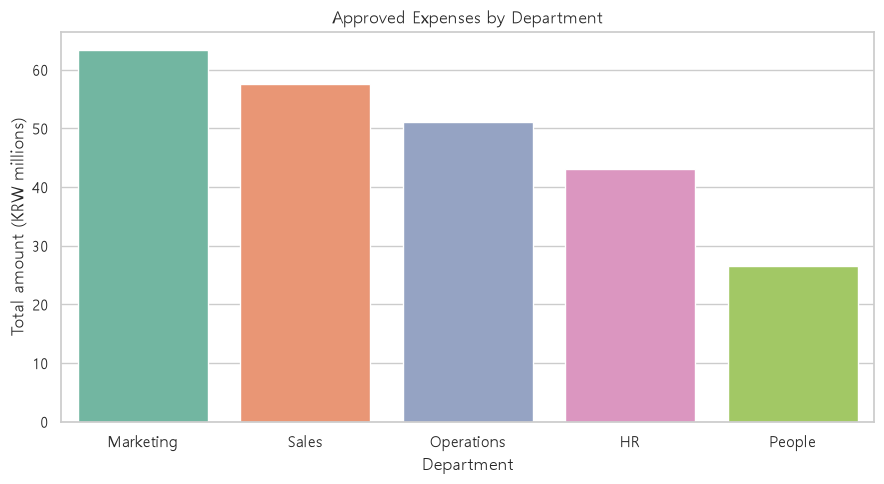

In [37]:
# Save English monthly line and department bar charts
monthly_plot = monthly_summary.dropna(subset=["month"]).sort_values("month").copy()
monthly_plot["month"] = monthly_plot["month"].astype(str)
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=monthly_plot, x="month", y="total_amount_krw", marker="o", ax=ax, color="#176B87")
ax.set(title="Approved Expenses by Month", xlabel="Month", ylabel="Total amount (KRW)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "monthly_total_english.png", dpi=180)
plt.show()
plt.close(fig)

department_plot = department_summary.copy()
department_plot["amount_million_krw"] = department_plot["total_amount_krw"] / 1_000_000
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=department_plot, x="department", y="amount_million_krw", hue="department", legend=False, palette="Set2", ax=ax)
ax.set(title="Approved Expenses by Department", xlabel="Department", ylabel="Total amount (KRW millions)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "department_total_english.png", dpi=180)
plt.show()
plt.close(fig)

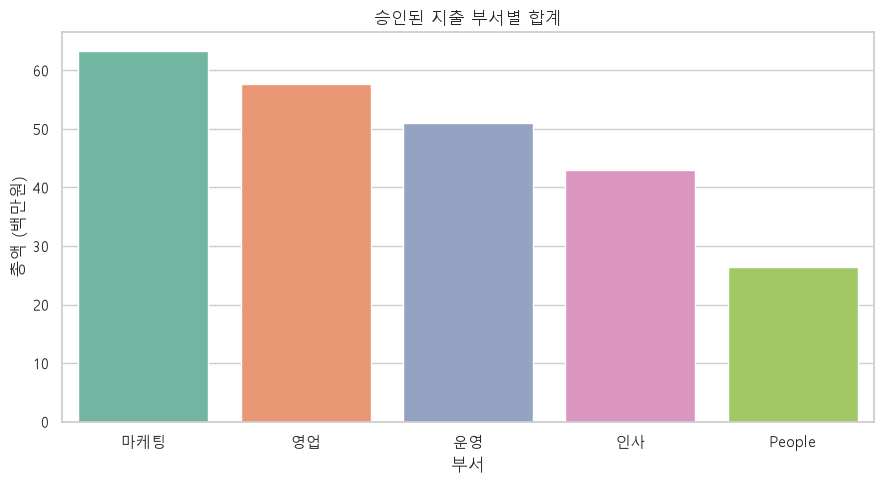

PNG chart exports completed.
['clean_expenses.xlsx', 'department_spend_en.png', 'department_spend_kr.png', 'department_total_english.png', 'department_total_korean.png', 'english_summaries.xlsx', 'expense_summary_en.xlsx', 'expense_summary_kr.xlsx', 'korean_summaries.xlsx', 'missing_values.xlsx', 'monthly_spend_en.png', 'monthly_total_english.png']


In [39]:
# Save the Korean department chart
KOREAN_DEPARTMENT = {"Marketing": "마케팅", "Sales": "영업", "Operations": "운영", "HR": "인사"}
korean_plot = department_plot.copy()
korean_plot["department_ko"] = korean_plot["department"].map(KOREAN_DEPARTMENT).fillna(korean_plot["department"])
plt.rcParams["font.family"] = "Malgun Gothic"
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=korean_plot, x="department_ko", y="amount_million_krw", hue="department_ko", legend=False, palette="Set2", ax=ax)
ax.set(title="승인된 지출 부서별 합계", xlabel="부서", ylabel="총액 (백만원)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "department_total_korean.png", dpi=180)
plt.show()
plt.close(fig)
print("PNG chart exports completed.")
print(sorted(path.name for path in OUTPUT_DIR.iterdir()))